In [2]:
from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import cv2
import os


TAMANIOS = {
          "Instagram": (1080, 1080),
          "Facebook": (1200, 630),
          "Twitter": (1600, 900),
          "Youtube": (1280, 720)
          }


def cargar_imagen(ruta):
    try:
        if ruta.startswith("http"):
          datos = requests.get(ruta).content
          return Image.open(BytesIO(datos)).convert("RGB")
        else:
          return Image.open(ruta).convert("RGB")
    except Exception as e:
        print("Error al cargar la imagen:", e)
        return None


def redimensionar_imagen(ruta, red_social):
    red_social = red_social.capitalize()


    if red_social not in TAMANIOS:
      print("Red social no válida.")
      return None


    img = cargar_imagen(ruta)
    if img is None:
      return None


    ancho_obj, alto_obj = TAMANIOS[red_social]


    # Mantener proporciones
    img.thumbnail((ancho_obj, alto_obj))


    # Guardar con nombre nuevo
    nombre_salida = f"imagen_{red_social}.jpg"
    img.save(nombre_salida)


    print(f"Imagen redimensionada guardada como {nombre_salida} ({img.size})")
    return nombre_salida

In [4]:
resultado = redimensionar_imagen("/content/2.jpg", "Youtube")
resultado

Error al cargar la imagen: [Errno 2] No such file or directory: '/content/2.jpg'


In [ ]:
def ecualizar_contraste(ruta, nombre_salida="ecualizada"):
    img = cargar_imagen(ruta)
    if img is None:
      return None


    # Convertir a grises
    img_gray = img.convert("L")
    img_array = np.array(img_gray)


    # Histograma y CDF
    hist, bins = np.histogram(img_array.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = 255 * cdf / cdf[-1]


    # Aplicar ecualización
    img_eq = np.interp(img_array.flatten(), bins[:-1], cdf_normalized)
    img_eq = img_eq.reshape(img_array.shape).astype('uint8')


    img_ecualizada_pil = Image.fromarray(img_eq)


    # Mostrar
    plt.figure(figsize=(10, 4))


    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")


    plt.subplot(1, 2, 2)
    plt.title("Ecualizada")
    plt.imshow(img_eq, cmap="gray")
    plt.axis("off")


    plt.show()


    # Guardar
    orig_path = f"{nombre_salida}_original.jpg"
    eq_path = f"{nombre_salida}_ecualizada.jpg"


    img.save(orig_path)
    img_ecualizada_pil.save(eq_path)


    print("Guardado:", orig_path)
    print("Guardado:", eq_path)


    return eq_path

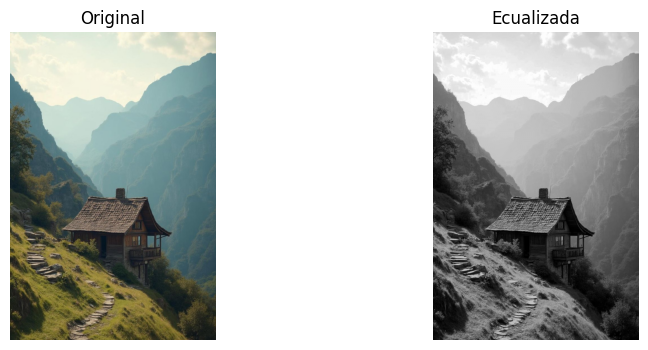

Guardado: ecualizada_original.jpg
Guardado: ecualizada_ecualizada.jpg


'ecualizada_ecualizada.jpg'

In [ ]:
ecualizar_contraste(resultado)


In [ ]:
FILTROS = {
"BLUR": ImageFilter.BLUR,
"CONTOUR": ImageFilter.CONTOUR,
"DETAIL": ImageFilter.DETAIL,
"EDGE_ENHANCE": ImageFilter.EDGE_ENHANCE,
"EDGE_ENHANCE_MORE": ImageFilter.EDGE_ENHANCE_MORE,
"EMBOSS": ImageFilter.EMBOSS,
"FIND_EDGES": ImageFilter.FIND_EDGES,
"SHARPEN": ImageFilter.SHARPEN,
"SMOOTH": ImageFilter.SMOOTH
}


def aplicar_filtro(ruta, filtro):

    filtro = filtro.upper()

    if filtro not in FILTROS:
      print("Filtro no válido.")
      return None


    img = cargar_imagen(ruta)
    if img is None:
        return None


    img_filtrada = img.filter(FILTROS[filtro])


    # Mostrar
    plt.figure(figsize=(8, 4))


    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")


    plt.subplot(1, 2, 2)
    plt.title(f"Filtro: {filtro}", color="red")
    plt.imshow(img_filtrada)
    plt.axis("off")


    plt.show()


    nombre_salida = f"filtro_{filtro}.jpg"
    img_filtrada.save(nombre_salida)
    print("Guardado:", nombre_salida)


    return nombre_salida

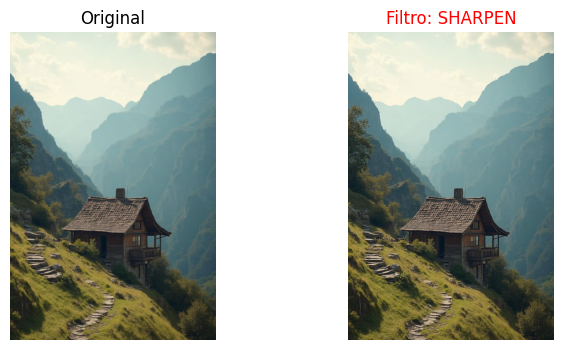

Guardado: filtro_SHARPEN.jpg


'filtro_SHARPEN.jpg'

In [ ]:
aplicar_filtro(resultado, 'SHARPEN')

In [ ]:
def generar_boceto(ruta, persona=True, invertir=True):

    if not persona:
        print("La IA detectó que no es una persona.")
        return None


    img = cargar_imagen(ruta)
    if img is None:
        return None


    # Convertir a OpenCV
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)


    gris = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    suave = cv2.GaussianBlur(gris, (5, 5), 0)


    bordes = cv2.Canny(suave, 50, 150)


    if invertir:
        boceto = cv2.bitwise_not(bordes)
    else:
        boceto = bordes


    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")


    plt.subplot(1, 3, 2)
    plt.title("Grises")
    plt.imshow(gris, cmap="gray")
    plt.axis("off")


    plt.subplot(1, 3, 3)
    plt.title("Boceto")
    plt.imshow(boceto, cmap="gray")
    plt.axis("off")


    plt.show()


    salida = "boceto_resultado.jpg"
    Image.fromarray(boceto).save(salida)
    print("Guardado:", salida)


    return salida

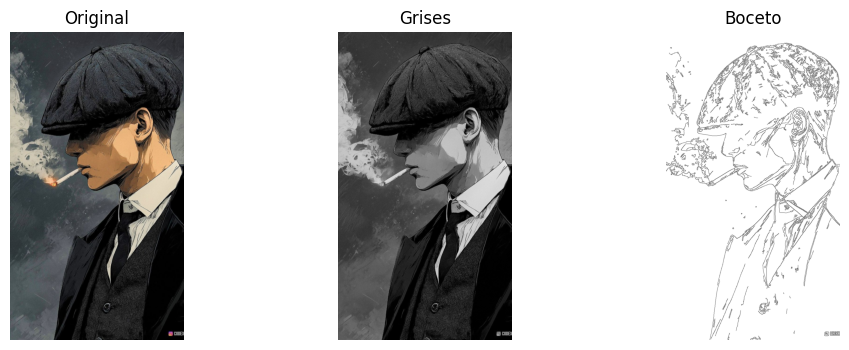

Guardado: boceto_resultado.jpg


'boceto_resultado.jpg'

In [ ]:
generar_boceto("/content/5.jpg", resultado)

In [ ]:
# JUSTIFICACIÓN PARA PINTORES/DIBUJANTES

# 1. Secuencia Técnica: Por qué se elige el método.
#    El boceto se genera con la secuencia:
#    Escala de Grises, Inversión, Desenfoque Gaussiano, División.
#    Esta cadena de procesamiento es esencial para aislar los bordes y las líneas de contorno.

# 2. Superioridad Comparativa: Por qué es la mejor herramienta.
#      Imagen Original / Grises: Demasiada información de color y textura sutil.
#      Boceto: Elimina el ruido y los tonos intermedios, proporcionando una plantilla limpia.
#      Esto permite al artista enfocarse solo en la PROPORCIÓN y ESTRUCTURA del dibujo,
#      que es el paso más crítico al inicio de cualquier retrato.

# La herramienta aísla la estructura (líneas) de los valores (sombra), haciendo el proceso
# de dibujo más eficiente para el usuario.